# Plot resonance wavefunction

In [1]:
from dvr import *

In [2]:
# define system parameters
n = 256                      # number of DVR grid points
phi = pi / 24                # rotation angle
real_res = 1.606 - 1j*0.047  # expected value of resonance
L = 50.0                     # system size

save_plots = True           # save plots or not

gauss_s = lambda r: 2.0 * exp(-((r-3.0)/1.5)**2) # potential

In [3]:
x_plot = np.linspace(0.0, L, 500)

## Resonance wavefunction without CS or EC

In [4]:
test_system = DVR(n, L, rotation_angle=0.0, potential=gauss_s)
eigval, eigstate = test_system.closest_to_resonance(real_res)
rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=False, regulator=False)
eigval = eigval[0]

resonance = test_system.construct_wavefunc(eigstate[:, 0], x_plot)

print("Energy and radius of resonance without complex scaling:")
print(f"\tE = {np.real(eigval):.3f} + j{np.imag(eigval):.3f}")
print(f"\t<r^2> = {np.real(rr):.3f} + j{np.imag(rr):.3f}")

Energy and radius of resonance without complex scaling:
	E = 1.590 + j0.000
	<r^2> = 108.661 + j0.000


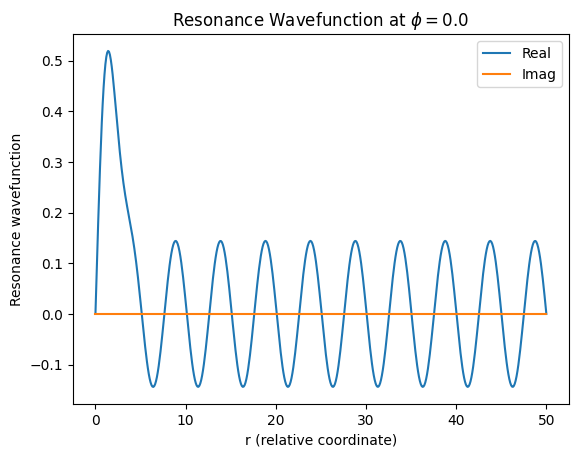

In [5]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$")
ax.legend()
if save_plots:
    plt.savefig("./plots/resonance_wavefunc_nocs.png")
plt.show()

## Resonance wavefunction at $\phi=\pi/24$ without EC

In [6]:
test_system = DVR(n, L, rotation_angle=pi/24, potential=gauss_s)
eigval, eigstate = test_system.closest_to_resonance(real_res)
rr = test_system.compute_r2(eigstate[:, 0], rotate_rr=True, regulator=False)
eigval = eigval[0]

resonance = test_system.construct_wavefunc(eigstate[:, 0], x_plot)

print("Energy and radius of resonance with complex scaling at phi=pi/24")
print(f"\tE = {np.real(eigval):.3f} + j{np.imag(eigval):.3f}")
print(f"\t<r^2> = {np.real(rr):.3f} + j{np.imag(rr):.3f}")

Energy and radius of resonance with complex scaling at phi=pi/24
	E = 1.606 + j-0.047
	<r^2> = 0.774 + j0.200


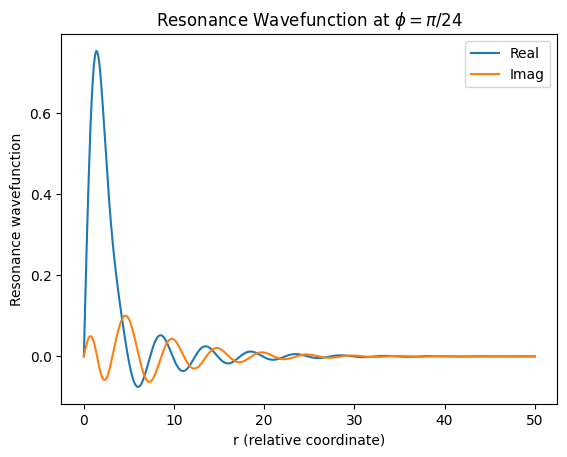

In [7]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=\pi/24$")
ax.legend()
if save_plots:
    plt.savefig("./plots/resonance_wavefunc_cs.png")
plt.show()

## Resonance wavefunction at $\phi=0.0$ with EC back-rotation

In [8]:
phi_train = np.linspace(pi/24, pi/6, 50)

test_EC = ECSystem(n, L, real_res, potential=gauss_s)
test_EC.train(phi_train)
test_EC.construct_basis()

phip = 0.0
predict_energy, predict_rr = test_EC.predict([phip], rotate_rr=False)
resonance = test_EC.grab_wavefunc_from_prediction(phip, x_plot)

print("Energy and radius of resonance at phi=0.0 using EC:")
print(f"\tE = {np.real(predict_energy[0]):.3f} + j{np.imag(predict_energy[0]):.3f}")
print(f"\t<r^2> = {np.real(predict_rr[0]):.3f} + j{np.imag(predict_rr[0]):.3f}")

Energy and radius of resonance at phi=0.0 using EC:
	E = 1.606 + j-0.047
	<r^2> = 0.777 + j0.197


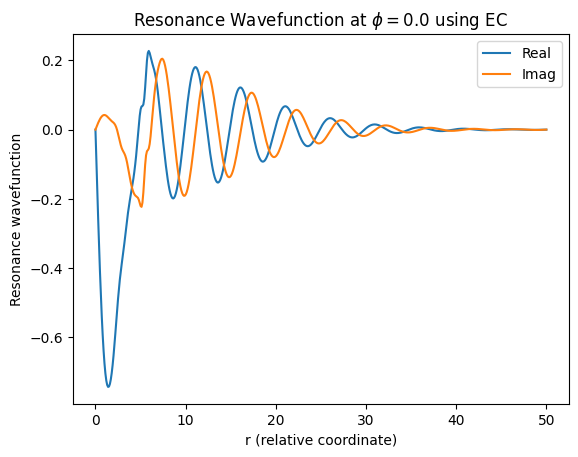

In [9]:
fig, ax = plt.subplots()
ax.plot(x_plot, np.real(resonance), label='Real')
ax.plot(x_plot, np.imag(resonance), label='Imag')
ax.set_xlabel("r (relative coordinate)")
ax.set_ylabel("Resonance wavefunction")
ax.set_title(r"Resonance Wavefunction at $\phi=0.0$ using EC")
ax.legend()
if save_plots:
    plt.savefig("./plots/resonance_wavefunc_ec.png")
plt.show()